In [1]:
import ROOT
import os
import glob

In [2]:
fileDirPath = "/d/home/septian/Moments2Amplitudes/brufit/"

files = glob.glob(os.path.join(fileDirPath, "MassDependentResults_*.root"))

print("Found files:")
for f in files:
    print(f)

Found files:
/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_15.root
/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_43.root
/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_22.root
/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_49.root
/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_40.root
/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_36.root
/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_8.root
/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_30.root
/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_19.root
/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_44.root
/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_46.root
/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_31.root
/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_48.root
/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_10

In [3]:
# out_log = []
chi2_values = []
# open text file with format "output_$num.txt"
for file in files:
    num = file.split("_")[-1].split(".")[0]
    print(f"Processing file: {file} with output log: output_{num}.txt")
    out_file = f"output_{num}.txt"
    if os.path.exists(out_file):
        with open(out_file, 'r') as f:
            # find lines with "Chi2 after minimization: " read number after it
            for line in f:
                if "Chi2 after minimization: " in line:
                    chi2_value = line.split(":")[-1].strip()
                    print(f"Found Chi2 value: {chi2_value} for file {file}")
                    chi2_values.append((file, float(chi2_value)))

Processing file: /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_15.root with output log: output_15.txt
Found Chi2 value: 67.5402 for file /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_15.root
Processing file: /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_43.root with output log: output_43.txt
Found Chi2 value: 75.6365 for file /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_43.root
Processing file: /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_22.root with output log: output_22.txt
Found Chi2 value: 76.6814 for file /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_22.root
Processing file: /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_49.root with output log: output_49.txt
Found Chi2 value: 61.13 for file /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_49.root
Processing file: /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_40.root with output lo

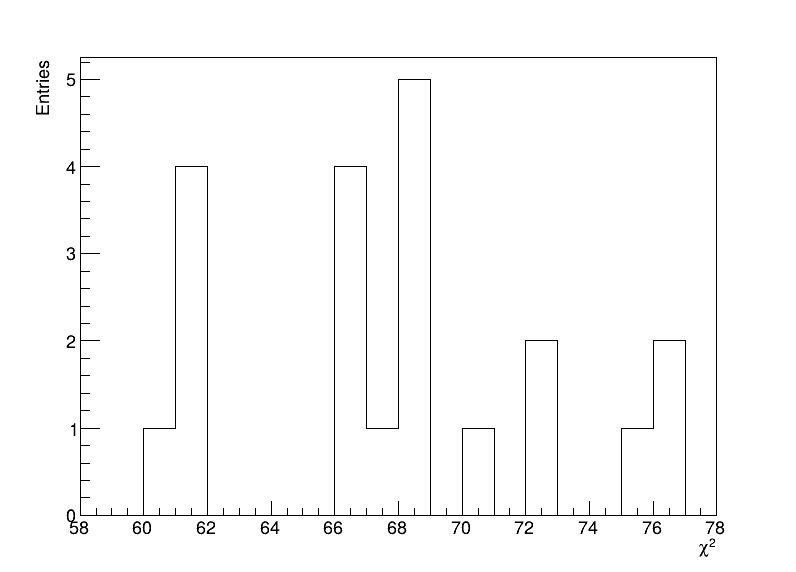

In [4]:
# print("Chi2 values:", chi2_values)
# Create a histogram to visualize the chi2 values
ROOT.gStyle.SetOptStat(0)
chi2_hist = ROOT.TH1F("chi2_hist", ";#chi^{2};Entries", 20, 58, 78)
for file, chi2 in chi2_values:
    chi2_hist.Fill(chi2)

canvas = ROOT.TCanvas("canvas", "Chi2 Histogram", 800, 600)
chi2_hist.SetLineColor(ROOT.kBlack)
chi2_hist.Draw()
canvas.Draw()

In [5]:
# find 5 files with the lowest chi2 value
chi2_values.sort(key=lambda x: x[1])
print("Top 5 files with lowest chi2 values:")
for file, chi2 in chi2_values[:5]:
    print(f"File: {file}, Chi2: {chi2}")

Top 5 files with lowest chi2 values:
File: /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_32.root, Chi2: 60.5515
File: /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_49.root, Chi2: 61.13
File: /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_31.root, Chi2: 61.2456
File: /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_44.root, Chi2: 61.6187
File: /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_40.root, Chi2: 61.9418


In [6]:
# create df for the 5 files with lowest chi2 value
root_files = []
for file, chi2 in chi2_values[:5]:
    print(f"Processing file: {file}")
    root_file = ROOT.TFile.Open(file)
    root_files.append(root_file)

tree_result = []
for root_file in root_files:
    tree = root_file.Get("result")
    if not tree:
        print(f"Tree 'result' not found in file {root_file.GetName()}")
        continue
    tree_result.append(tree)

Processing file: /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_32.root
Processing file: /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_49.root
Processing file: /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_31.root
Processing file: /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_44.root
Processing file: /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_40.root


In [7]:
tree_result[0].Print()  # Print the structure of the first tree

******************************************************************************
*Tree    :result    : result                                                 *
*Entries :        8 : Total =           24217 bytes  File  Size =       7025 *
*        :          : Tree compression factor =   1.00                       *
******************************************************************************
*Br    0 :mass_bin  : mass_bin/D                                             *
*Entries :        8 : Total  Size=        646 bytes  File Size  =        141 *
*Baskets :        1 : Basket Size=      32000 bytes  Compression=   1.00     *
*............................................................................*
*Br    1 :a_0_0     : a_0_0/D                                                *
*Entries :        8 : Total  Size=        631 bytes  File Size  =        138 *
*Baskets :        1 : Basket Size=      32000 bytes  Compression=   1.00     *
*...................................................

In [8]:
def MakeAmplitudeSqrVsMass(tree, amp_name):
    gr = ROOT.TGraph()
    gr.SetName(f"{amp_name}_sqr_vs_mass")
    gr.SetTitle(f"{amp_name} squared vs Mass")
    gr.GetXaxis().SetTitle("Mass (GeV/c^{2})")
    gr.GetYaxis().SetTitle(f"{amp_name} squared (GeV/c^{2})^{2}")
    tree.SetBranchStatus("*", 0)  # Disable all branches
    tree.SetBranchStatus("mass_bin", 1)  # Enable only mass_bin branch
    tree.SetBranchStatus(amp_name, 1)  # Enable the specific amplitude branch
    for entry in tree:
        mass = tree.GetLeaf("mass_bin").GetValue()
        amp_value = tree.GetLeaf(amp_name).GetValue()
        gr.SetPoint(gr.GetN(), mass, 2*amp_value*amp_value)
    return gr

In [9]:
df = ROOT.RDataFrame(tree_result[0])
col_names = df.GetColumnNames()

In [10]:
# print("Column names in the DataFrame:", col_names)
amp_col_names = [col for col in col_names if not col.startswith("aphi_") and not col.startswith("bphi_") and not col.startswith("mass_bin")]

print("Amplitude column names:")
for col in amp_col_names:
    print(col)

Amplitude column names:
a_0_0
a_1_-1
a_1_0
a_1_1
a_2_-1
a_2_-2
a_2_0
a_2_1
a_2_2
b_0_0
b_1_-1
b_1_0
b_1_1
b_2_-1
b_2_-2
b_2_0
b_2_1
b_2_2


In [11]:
gr_amp_vs_mass = {}
for itree in range(len(tree_result)):
    tree = tree_result[itree]
    chi2 = chi2_values[itree][1]
    for amp_name in amp_col_names:
        print(f"Processing amplitude: {amp_name} for tree {itree}")
        gr = MakeAmplitudeSqrVsMass(tree, f"{amp_name}")
        gr_amp_vs_mass[f"{amp_name}_{itree}"] = [chi2, gr]

Processing amplitude: a_0_0 for tree 0
Processing amplitude: a_1_-1 for tree 0
Processing amplitude: a_1_0 for tree 0
Processing amplitude: a_1_1 for tree 0
Processing amplitude: a_2_-1 for tree 0
Processing amplitude: a_2_-2 for tree 0
Processing amplitude: a_2_0 for tree 0
Processing amplitude: a_2_1 for tree 0
Processing amplitude: a_2_2 for tree 0
Processing amplitude: b_0_0 for tree 0
Processing amplitude: b_1_-1 for tree 0
Processing amplitude: b_1_0 for tree 0
Processing amplitude: b_1_1 for tree 0
Processing amplitude: b_2_-1 for tree 0
Processing amplitude: b_2_-2 for tree 0
Processing amplitude: b_2_0 for tree 0
Processing amplitude: b_2_1 for tree 0
Processing amplitude: b_2_2 for tree 0
Processing amplitude: a_0_0 for tree 1
Processing amplitude: a_1_-1 for tree 1
Processing amplitude: a_1_0 for tree 1
Processing amplitude: a_1_1 for tree 1
Processing amplitude: a_2_-1 for tree 1
Processing amplitude: a_2_-2 for tree 1
Processing amplitude: a_2_0 for tree 1
Processing ampli

In [12]:
import sys
sys.path.append("/d/home/septian/EtaPi0Analysis/jupyter_notebook/")
import BruFitResults as FitResults

In [13]:
fit_result_dir_Phase1_GlueX2020_nominal = "/d/home/septian/EtaPi0Analysis/run_merged/fitMoment_GlueX1_2019_11_t010100_m010200_MCMCN6000BI1000S08WCOV_R6.34/"

mass_name = "Mpi0eta"
N_mass_bin = 30
mass_bin_width = 0.04
first_mass_bin_center = 0.82

mass_bin = [first_mass_bin_center + mass_bin_width * i for i in range(N_mass_bin)]
mass_bin_dir = [f"{mass_name}{mass:.6f}_/" for mass in mass_bin]

MCMCResults_Phase1_GlueX2020_nominal = FitResults.MomentsMCMC(fit_result_dir_Phase1_GlueX2020_nominal, mass_bin_dir, mass_name)

In [14]:
gr_H000 = MCMCResults_Phase1_GlueX2020_nominal.load_saved_unnormalized_moments_vs_mass(fit_result_dir_Phase1_GlueX2020_nominal + "Moments_unnormalized_vs_mass_Phase1_GlueX2020.root", "H_0_0_0")

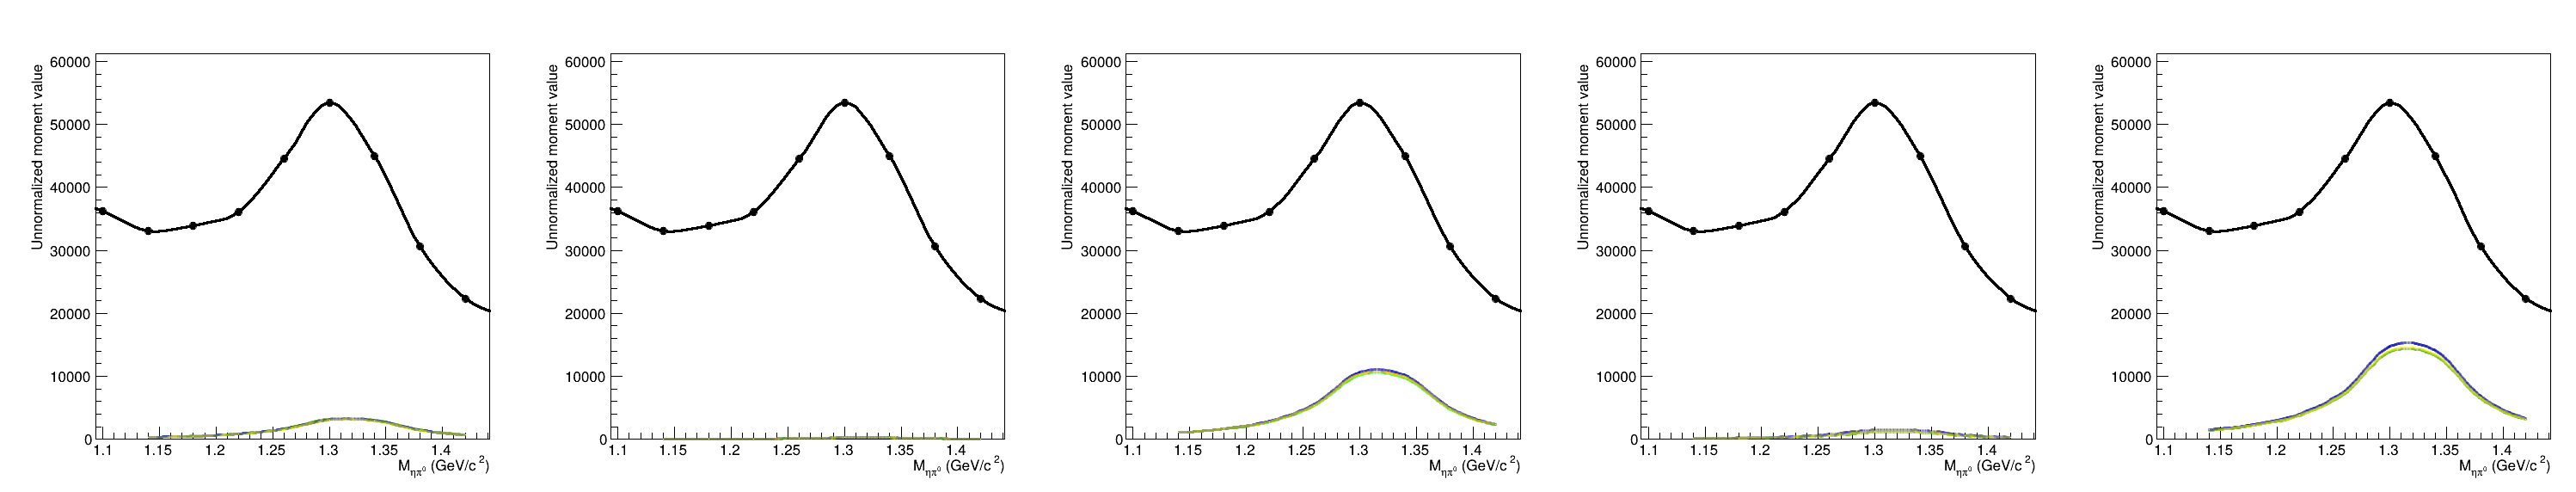

In [15]:
canvas_a_2 = ROOT.TCanvas("canvas_a_2", "D-waves positive refl amp. squared vs Mass", 3000, 600)
ROOT.gStyle.SetOptTitle(0)

refl_dict = {"a": "+", "b": "-"}
l_dict = {"0": "S", "1": "P", "2": "D", "3": "F", "4": "G"}

col_a_2_names = [col for col in amp_col_names if col.startswith("a_2")]
canvas_a_2.Divide(len(col_a_2_names), 1)
for j,name in enumerate(col_a_2_names):
    canvas_a_2.cd(j+1)
    gr_H000.Draw("APC")  # Draw the H_0_0_0 graph with axis
    gr_H000.GetXaxis().SetRangeUser(1.10, 1.44)
    gr_H000.SetMinimum(0.0)
    gr_H000.SetLineWidth(3)

    ROOT.gPad.SetLeftMargin(0.15)
    ROOT.gPad.SetRightMargin(0.0)
    refl,l,m = name.split("_")
    for i in range(len(tree_result)):
        # canvas_a_2_2.cd(i + 1)
        chi2, gr = gr_amp_vs_mass[f"{name}_{i}"]
        gr.SetMarkerColor(i + 1)
        gr.SetLineColorAlpha(i + 1, 0.2)
        gr.SetLineWidth(3)
        # gr.SetMarkerStyle(20 + i)
        # gr.SetTitle(f"a_2_2 vs Mass (Chi2: {chi2})")
        gr.SetTitle("#chi^{2} = " + f"{chi2:.2f}")
        gr.GetXaxis().SetTitle("M_{#eta#pi^{0}} (GeV/c^{2})")
        gr.GetYaxis().SetTitle(f"|{l_dict[l]}^{{{refl_dict[refl]}}}_{{{m}}}|^{{{2}}}")
        # if i == 0:
        #     gr.Draw("APC")  # Draw the first graph with axis
        # else:
            # gr.DrawClone("PC same")
        gr.DrawClone("PC same")

# canvas_a_2_2.BuildLegend()
canvas_a_2.Draw()

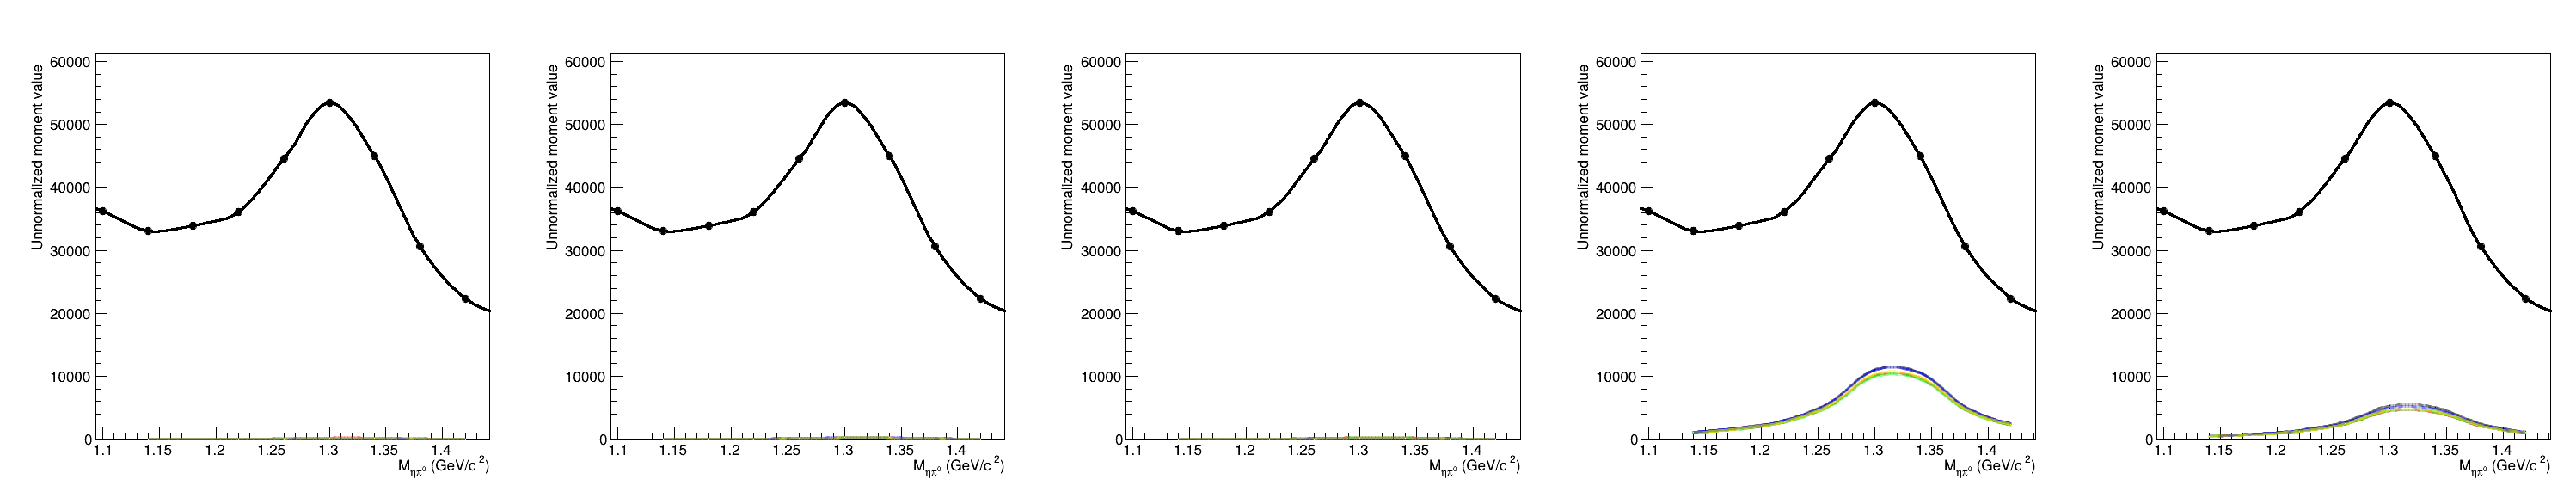

In [16]:
canvas_b_2 = ROOT.TCanvas("canvas_b_2", "D-waves negative refl amp. squared vs Mass", 3000, 600)
canvas_b_2.Divide(len(col_a_2_names), 1)
col_b_2_names = [col for col in amp_col_names if col.startswith("b_2")]
for j,name in enumerate(col_b_2_names):
    canvas_b_2.cd(j+1)
    gr_H000.Draw("APC")  # Draw the H_0_0_0 graph with axis
    gr_H000.GetXaxis().SetRangeUser(1.10, 1.44)
    gr_H000.SetMinimum(0.0)
    gr_H000.SetLineWidth(3)

    ROOT.gPad.SetLeftMargin(0.15)
    ROOT.gPad.SetRightMargin(0.0)
    refl,l,m = name.split("_")
    for i in range(len(tree_result)):
        chi2, gr = gr_amp_vs_mass[f"{name}_{i}"]
        gr.SetMarkerColor(i + 1)
        gr.SetLineColorAlpha(i + 1, 0.2)
        gr.SetLineWidth(3)
        # gr.SetMarkerStyle(20 + i)
        # gr.SetTitle(f"a_2_2 vs Mass (Chi2: {chi2})")
        gr.SetTitle("#chi^{2} = " + f"{chi2:.2f}")
        gr.GetXaxis().SetTitle("M_{#eta#pi^{0}} (GeV/c^{2})")
        gr.GetYaxis().SetTitle(f"|{l_dict[l]}^{{{refl_dict[refl]}}}_{{{m}}}|^{{{2}}}")
        # if i == 0:
        #     gr.Draw("APC")  # Draw the first graph with axis
        # else:
            # gr.DrawClone("PC same")
        gr.DrawClone("PC same")

canvas_b_2.Draw()

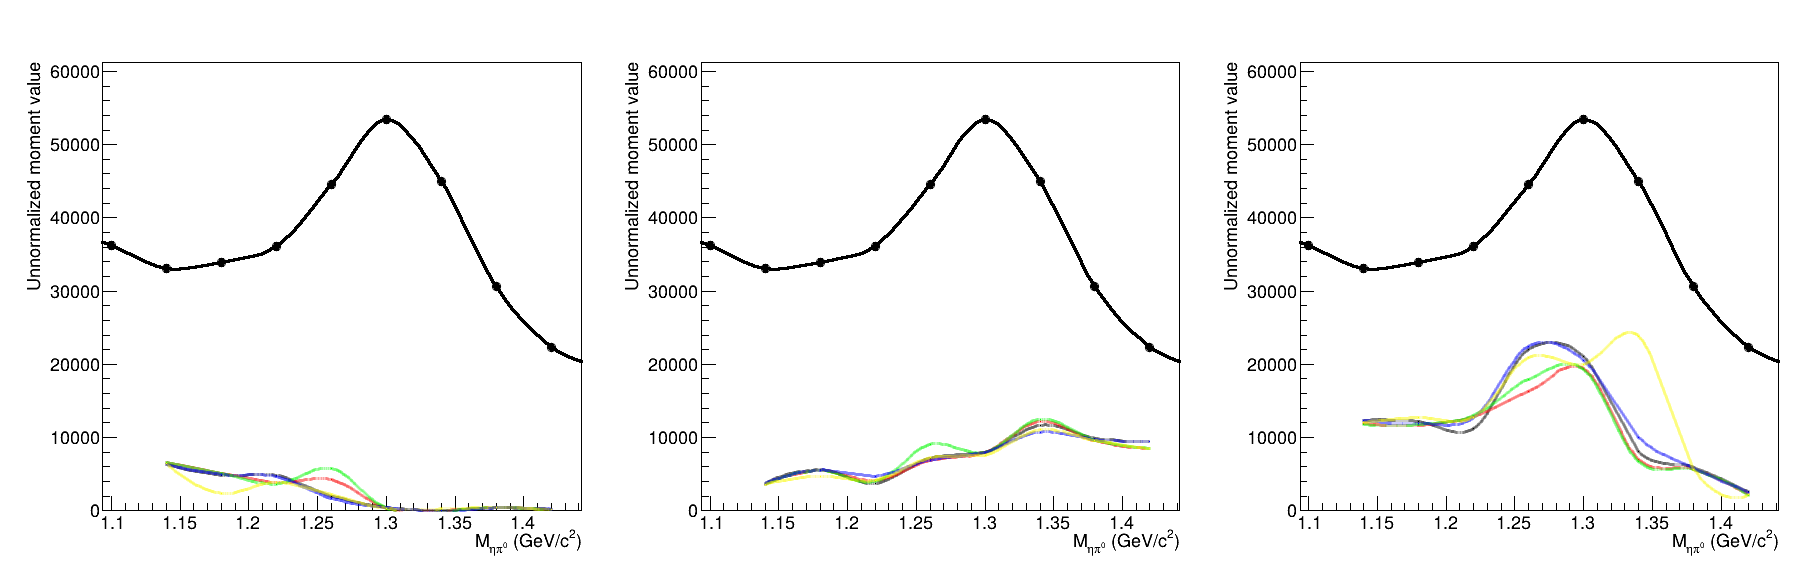

In [17]:
a_1_names = [col for col in amp_col_names if col.startswith("a_1")]
canvas_a_1 = ROOT.TCanvas("canvas_a_1", "P-waves positive refl amp. squared vs Mass", 1800, 600)
canvas_a_1.Divide(len(a_1_names), 1)
for j,name in enumerate(a_1_names):
    canvas_a_1.cd(j+1)
    gr_H000.Draw("APC")  # Draw the H_0_0_0 graph with axis
    gr_H000.GetXaxis().SetRangeUser(1.10, 1.44)
    gr_H000.SetMinimum(0.0)
    gr_H000.SetLineWidth(3)

    ROOT.gPad.SetLeftMargin(0.15)
    ROOT.gPad.SetRightMargin(0.0)
    refl,l,m = name.split("_")
    for i in range(len(tree_result)):
        chi2, gr = gr_amp_vs_mass[f"{name}_{i}"]
        gr.SetMarkerColor(i + 1)
        gr.SetLineColorAlpha(i + 1, 0.2)
        gr.SetLineWidth(3)
        # gr.SetMarkerStyle(20 + i)
        # gr.SetTitle(f"a_2_2 vs Mass (Chi2: {chi2})")
        gr.SetTitle("#chi^{2} = " + f"{chi2:.2f}")
        gr.GetXaxis().SetTitle("M_{#eta#pi^{0}} (GeV/c^{2})")
        gr.GetYaxis().SetTitle(f"|{l_dict[l]}^{{{refl_dict[refl]}}}_{{{m}}}|^{{{2}}}")
        # if i == 0:
        #     gr.Draw("APC")  # Draw the first graph with axis
        # else:
            # gr.DrawClone("PC same")
        gr.DrawClone("PC same")

# canvas_a_1.BuildLegend()
canvas_a_1.Draw()

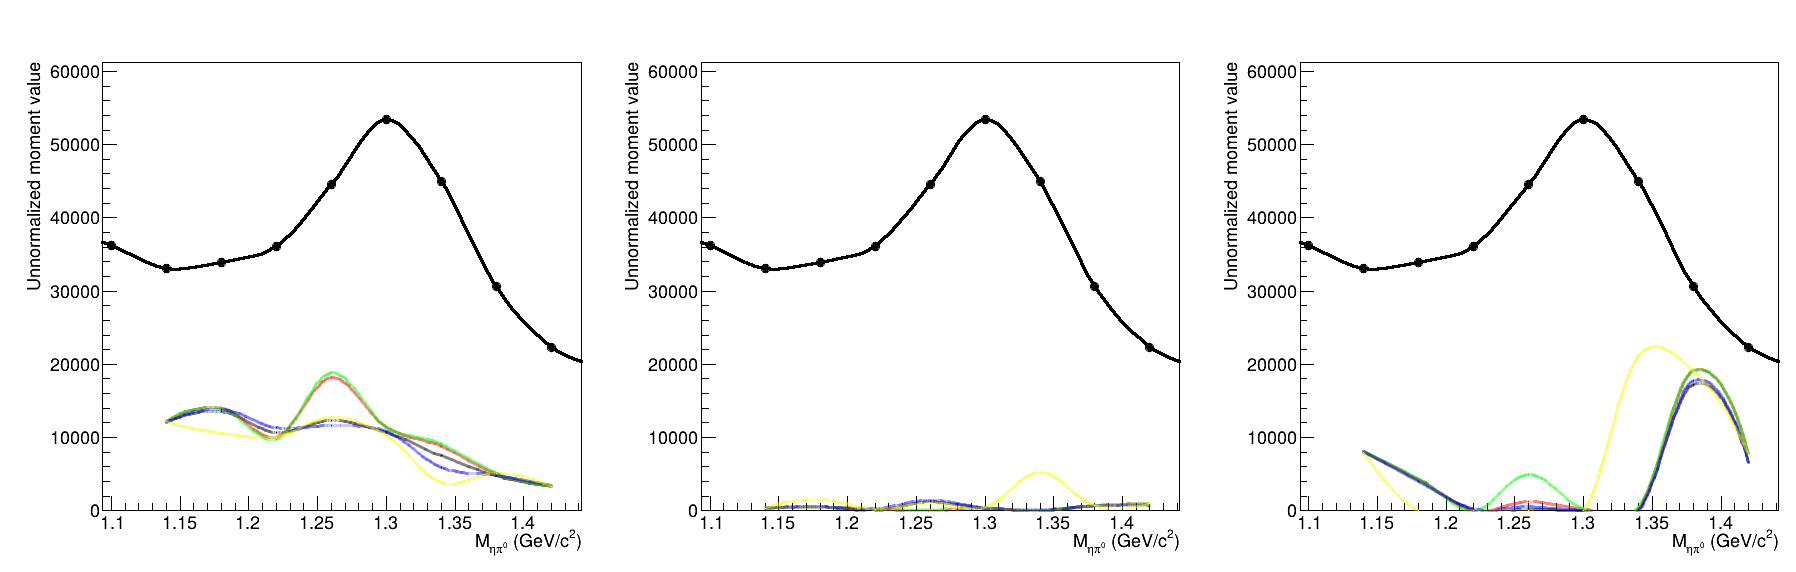

In [18]:
b_1_names = [col for col in amp_col_names if col.startswith("b_1")]
canvas_b_1 = ROOT.TCanvas("canvas_b_1", "P-waves negative refl amp. squared vs Mass", 1800, 600)
canvas_b_1.Divide(len(b_1_names), 1)
for j,name in enumerate(b_1_names):
    canvas_b_1.cd(j+1)
    gr_H000.Draw("APC")  # Draw the H_0_0_0 graph with axis
    gr_H000.GetXaxis().SetRangeUser(1.10, 1.44)
    gr_H000.SetMinimum(0.0)
    gr_H000.SetLineWidth(3)

    ROOT.gPad.SetLeftMargin(0.15)
    ROOT.gPad.SetRightMargin(0.0)
    refl,l,m = name.split("_")
    for i in range(len(tree_result)):
        chi2, gr = gr_amp_vs_mass[f"{name}_{i}"]
        gr.SetMarkerColor(i + 1)
        gr.SetLineColorAlpha(i + 1, 0.2)
        gr.SetLineWidth(3)
        # gr.SetMarkerStyle(20 + i)
        # gr.SetTitle(f"a_2_2 vs Mass (Chi2: {chi2})")
        gr.SetTitle("#chi^{2} = " + f"{chi2:.2f}")
        gr.GetXaxis().SetTitle("M_{#eta#pi^{0}} (GeV/c^{2})")
        gr.GetYaxis().SetTitle(f"|{l_dict[l]}^{{{refl_dict[refl]}}}_{{{m}}}|^{{{2}}}")
        # if i == 0:
        #     gr.Draw("APC")  # Draw the first graph with axis
        # else:
            # gr.DrawClone("PC same")
        gr.DrawClone("PC same")

# canvas_b_1.BuildLegend()
canvas_b_1.Draw()

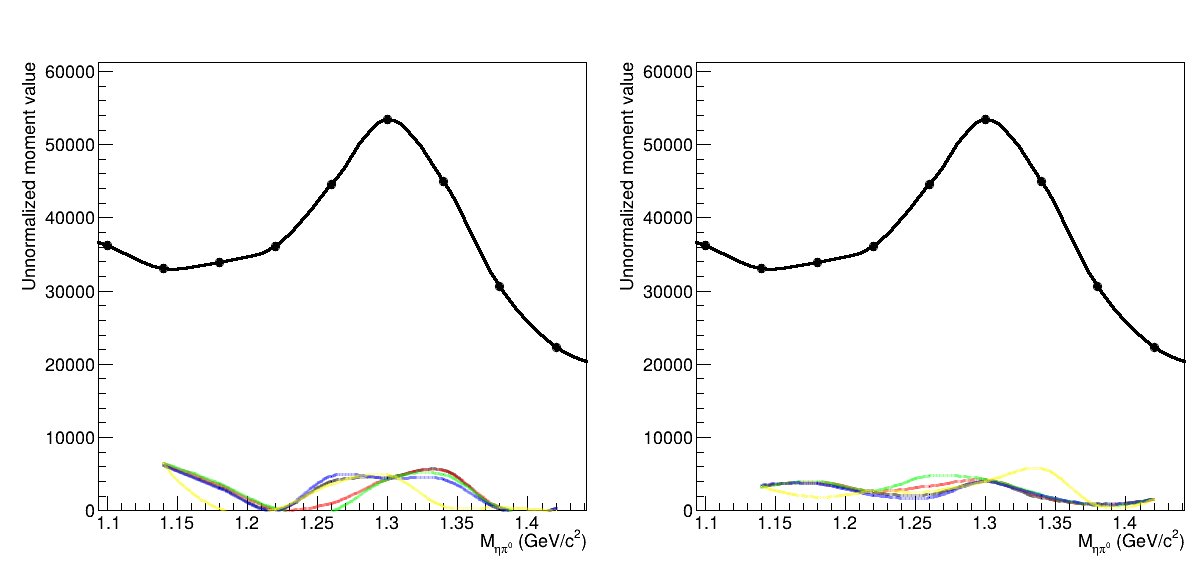

In [19]:
ab_0_names = [col for col in amp_col_names if col.startswith("a_0") or col.startswith("b_0")]

canvas_ab_0 = ROOT.TCanvas("canvas_ab_0", "S-waves positive and negative refl amp. squared vs Mass", 1200, 600)
canvas_ab_0.Divide(len(ab_0_names), 1)
for j,name in enumerate(ab_0_names):
    canvas_ab_0.cd(j+1)
    gr_H000.Draw("APC")  # Draw the H_0_0_0 graph with axis
    gr_H000.GetXaxis().SetRangeUser(1.10, 1.44)
    gr_H000.SetMinimum(0.0)
    gr_H000.SetLineWidth(3)

    ROOT.gPad.SetLeftMargin(0.15)
    ROOT.gPad.SetRightMargin(0.0)
    refl,l,m = name.split("_")
    for i in range(len(tree_result)):
        chi2, gr = gr_amp_vs_mass[f"{name}_{i}"]
        gr.SetMarkerColor(i + 1)
        gr.SetLineColorAlpha(i + 1, 0.2)
        gr.SetLineWidth(3)
        # gr.SetMarkerStyle(20 + i)
        # gr.SetTitle(f"a_2_2 vs Mass (Chi2: {chi2})")
        gr.SetTitle("#chi^{2} = " + f"{chi2:.2f}")
        gr.GetXaxis().SetTitle("M_{#eta#pi^{0}} (GeV/c^{2})")
        gr.GetYaxis().SetTitle(f"|{l_dict[l]}^{{{refl_dict[refl]}}}_{{{m}}}|^{{{2}}}")
        # if i == 0:
        #     gr.Draw("APC")  # Draw the first graph with axis
        # else:
            # gr.DrawClone("PC same")
        gr.DrawClone("PC same")

# canvas_ab_0.BuildLegend()
canvas_ab_0.Draw()